In [1]:
from langgraph.graph import MessagesState
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
import os
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, RemoveMessage
from langgraph.graph import StateGraph, START
from langgraph.checkpoint.memory import InMemorySaver

e:\LangGraph\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

True

In [3]:
llm= HuggingFaceEndpoint(
    repo_id='deepseek-ai/DeepSeek-V3.1-Terminus',
    task="text-generation",
    huggingfacehub_api_token=os.getenv("HUGGINGFACEHUB_API_TOKEN"),
)


model= ChatHuggingFace(llm=llm)

In [4]:
class ChatState(MessagesState):
    summary: str

In [5]:
def summarize_conversation(state: ChatState):

    existing_summary = state["summary"]

    # Build summarization prompt
    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."

    messages_for_summary = state["messages"] + [
        HumanMessage(content=prompt)
    ]

    response = model.invoke(messages_for_summary)

    # Keep only last 2 messages verbatim
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [6]:
def chat_node(state: ChatState):
    messages = []

    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Conversation summary:\n{state['summary']}"
        })

    messages.extend(state["messages"])

    print(messages)

    response = model.invoke(messages)
    return {"messages": [response]}

In [7]:
def should_summarize(state: ChatState):
    return len(state["messages"]) > 6

In [8]:
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)
builder.add_node("summarize", summarize_conversation)

builder.add_edge(START, "chat")

builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True: "summarize",
        False: "__end__",
    }
)

builder.add_edge("summarize", "__end__")



In [9]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

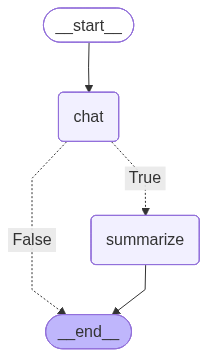

In [10]:
graph

In [11]:
config = {"configurable": {"thread_id": "t1"}}

def run_turn(text: str):
    out = graph.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config)
    return out

In [12]:
# gives the current version of the state
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [13]:
run_turn('Quantum Physics')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='3e82889c-9c6f-4ca9-a2b0-06c272f79e2f')]

--- STATE ---
summary: 
num_messages: 2
messages:
- HumanMessage : Quantum Physics
- AIMessage : Of course! Quantum physics (or quantum mechanics) is the fundamental theory in p


In [14]:
run_turn('How is Albert Einstien related?')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='3e82889c-9c6f-4ca9-a2b0-06c272f79e2f'), AIMessage(content='Of course! Quantum physics (or quantum mechanics) is the fundamental theory in physics that describes the behavior of matter and energy at the smallest scales—typically atomic and subatomic levels. It is one of the most successful and accurately tested theories in science, forming the basis for much of modern technology.\n\nHere is a breakdown of its core concepts, from the basics to its profound implications.\n\n### The Core Problem: The Classical World Fails\n\nBefore quantum mechanics, classical physics (Newton\'s laws, Maxwell\'s equations) worked brilliantly for everyday objects. But by the late 19th century, experiments revealed phenomena that classical physics couldn\'t explain:\n*   **Blackbody Radiation:** The spectrum of light emitted by hot objects.\n*   **The Photoelectric Effect:** Shining light on a metal can eject electrons, 

In [15]:
run_turn('What are some of Einstien"s fampus work')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='3e82889c-9c6f-4ca9-a2b0-06c272f79e2f'), AIMessage(content='Of course! Quantum physics (or quantum mechanics) is the fundamental theory in physics that describes the behavior of matter and energy at the smallest scales—typically atomic and subatomic levels. It is one of the most successful and accurately tested theories in science, forming the basis for much of modern technology.\n\nHere is a breakdown of its core concepts, from the basics to its profound implications.\n\n### The Core Problem: The Classical World Fails\n\nBefore quantum mechanics, classical physics (Newton\'s laws, Maxwell\'s equations) worked brilliantly for everyday objects. But by the late 19th century, experiments revealed phenomena that classical physics couldn\'t explain:\n*   **Blackbody Radiation:** The spectrum of light emitted by hot objects.\n*   **The Photoelectric Effect:** Shining light on a metal can eject electrons, 

In [16]:
run_turn('Explain special theory of relativity')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='3e82889c-9c6f-4ca9-a2b0-06c272f79e2f'), AIMessage(content='Of course! Quantum physics (or quantum mechanics) is the fundamental theory in physics that describes the behavior of matter and energy at the smallest scales—typically atomic and subatomic levels. It is one of the most successful and accurately tested theories in science, forming the basis for much of modern technology.\n\nHere is a breakdown of its core concepts, from the basics to its profound implications.\n\n### The Core Problem: The Classical World Fails\n\nBefore quantum mechanics, classical physics (Newton\'s laws, Maxwell\'s equations) worked brilliantly for everyday objects. But by the late 19th century, experiments revealed phenomena that classical physics couldn\'t explain:\n*   **Blackbody Radiation:** The spectrum of light emitted by hot objects.\n*   **The Photoelectric Effect:** Shining light on a metal can eject electrons, 